# Entrenamiento y evaluación de modelos

En este notebook se entrenarán distintos modelos de clasificación utilizando el conjunto de datos analizado previamente.

El objetivo consiste en comparar el desempeño de un Árbol de Decisión y un Random Forest mediante distintas métricas de evaluación. Además, se utilizará una búsqueda en grilla (`GridSearchCV`) para seleccionar los mejores hiperparámetros de cada modelo.

In [58]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

In [59]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

## División del conjunto de datos

Antes de entrenar los modelos se divide el conjunto de datos en entrenamiento y prueba.

Se utiliza una partición estratificada para conservar aproximadamente la misma proporción de cada clase en ambos subconjuntos.

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


## Modelo 1: Árbol de decisión

Se construye un Pipeline que contiene el preprocesamiento y el modelo.

Posteriormente se utiliza GridSearchCV para seleccionar la mejor combinación de hiperparámetros mediante validación cruzada.

In [61]:
tree_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [62]:
tree_param_grid = {
    "model__max_depth": [3,5,7,None],
    "model__min_samples_leaf": [1,2,5]
}

In [63]:
tree_grid = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print(tree_grid.best_params_)

{'model__max_depth': 5, 'model__min_samples_leaf': 5}


In [64]:
best_tree = tree_grid.best_estimator_

tree_pred = best_tree.predict(X_test)
tree_prob = best_tree.predict_proba(X_test)[:,1]

In [65]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89        42
           1       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



---
## Modelo 2: Random Forest

Se repite el procedimiento utilizando un Random Forest.

In [66]:
forest_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42))
])

In [67]:
forest_param_grid = {
    "model__n_estimators":[100,200],
    "model__max_depth":[None,5,10]
}

In [68]:
forest_grid = GridSearchCV(
    estimator=forest_pipeline,
    param_grid=forest_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

forest_grid.fit(X_train, y_train)

print(forest_grid.best_params_)

{'model__max_depth': None, 'model__n_estimators': 200}


In [69]:
best_forest = forest_grid.best_estimator_

forest_pred = best_forest.predict(X_test)
forest_prob = best_forest.predict_proba(X_test)[:,1]

In [70]:
print(classification_report(y_test, forest_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



---
## Comparación de métricas

Se comparan ambos modelos utilizando Accuracy, Precision, Recall, F1-score y ROC-AUC.

In [71]:
results = pd.DataFrame({
    "Modelo":["Decision Tree","Random Forest"],
    "Accuracy":[
        accuracy_score(y_test,tree_pred),
        accuracy_score(y_test,forest_pred)
    ],
    "Precision":[
        precision_score(y_test,tree_pred),
        precision_score(y_test,forest_pred)
    ],
    "Recall":[
        recall_score(y_test,tree_pred),
        recall_score(y_test,forest_pred)
    ],
    "F1":[
        f1_score(y_test,tree_pred),
        f1_score(y_test,forest_pred)
    ],
    "ROC AUC":[
        roc_auc_score(y_test,tree_prob),
        roc_auc_score(y_test,forest_prob)
    ]
})

results

,Modelo,Accuracy,Precision,Recall,F1,ROC AUC
0,Decision Tree,0.921053,0.943662,0.930556,0.937063,0.936839
1,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993221


In [72]:
tree_pipeline = Pipeline([
    ("model", DecisionTreeClassifier(random_state=42))
])

In [73]:
forest_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])

En este caso no se incluye un escalado de las variables, ya que los modelos basados en árboles toman decisiones mediante comparaciones entre valores y no dependen de distancias ni de productos internos. Sin embargo, se utiliza Pipeline como buena práctica para encapsular el flujo de entrenamiento y facilitar la reproducibilidad del proceso.

## Matrices de confusión

La matriz de confusión permite analizar el tipo de errores cometidos por cada modelo.

En particular, resulta útil distinguir entre falsos positivos y falsos negativos, información que no puede obtenerse únicamente mediante la métrica Accuracy.

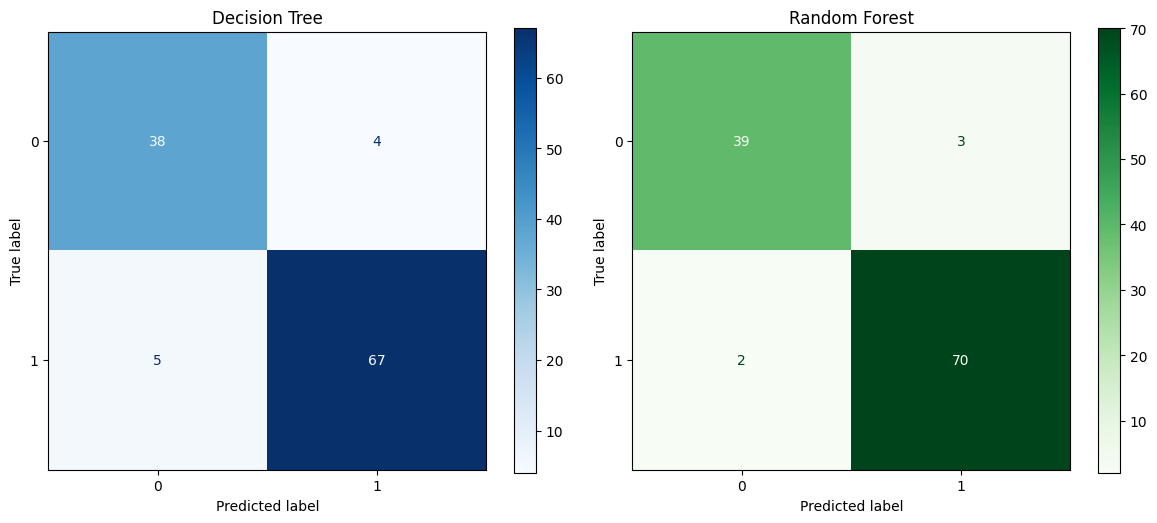

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_pred,
    ax=ax[0],
    cmap="Blues"
)
ax[0].set_title("Decision Tree")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_pred,
    ax=ax[1],
    cmap="Greens"
)
ax[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

### Interpretación

Ambos modelos presentan un buen desempeño general. Sin embargo, el Random Forest comete una menor cantidad de errores de clasificación, especialmente sobre la clase minoritaria, lo que refleja una mejor capacidad de generalización.

## Curvas ROC

La curva ROC muestra el compromiso entre la tasa de verdaderos positivos y la tasa de falsos positivos para distintos umbrales de clasificación.

El área bajo la curva (ROC-AUC) resume esta información en un único valor comprendido entre 0.5 y 1.

<Figure size 700x600 with 0 Axes>

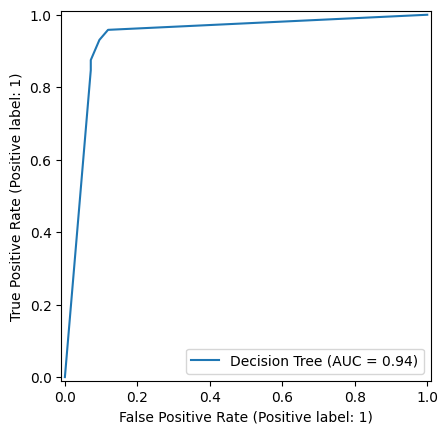

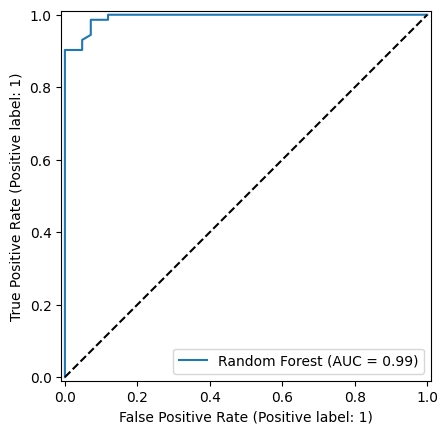

In [75]:
plt.figure(figsize=(7,6))

RocCurveDisplay.from_predictions(
    y_test,
    tree_prob,
    name="Decision Tree"
)

RocCurveDisplay.from_predictions(
    y_test,
    forest_prob,
    name="Random Forest"
)

plt.plot([0,1],[0,1],"k--")

plt.show()

### Interpretación

Cuanto más cercana se encuentre la curva al vértice superior izquierdo, mejor será la capacidad discriminatoria del modelo.

El valor ROC-AUC permite comparar ambos clasificadores independientemente del umbral elegido.

## Importancia de las variables

Una ventaja de Random Forest consiste en que permite estimar la importancia relativa de cada variable en las decisiones tomadas por el modelo.

Esto facilita interpretar qué características aportan mayor información para la clasificación.

In [76]:
importancias = pd.Series(
    best_forest.named_steps["model"].feature_importances_,
    index=X.columns
).sort_values()

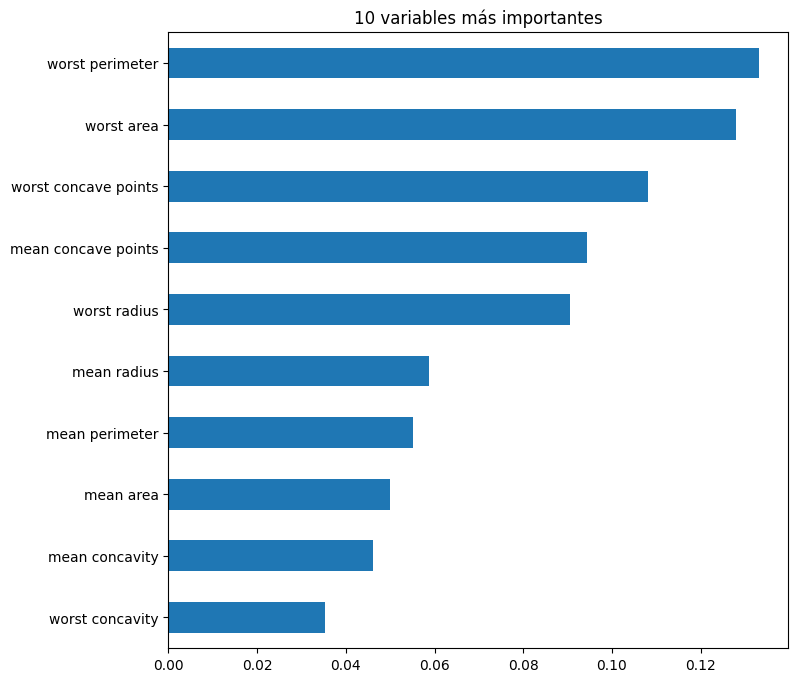

In [77]:
plt.figure(figsize=(8,8))

importancias.tail(10).plot.barh()

plt.title("10 variables más importantes")

plt.show()

# Conclusiones

En este trabajo se comparó el desempeño de un Árbol de Decisión y un Random Forest para clasificar tumores como benignos o malignos.

Se utilizó GridSearchCV para seleccionar los hiperparámetros de cada modelo mediante validación cruzada.

Los resultados obtenidos muestran que Random Forest alcanzó el mejor desempeño en la mayoría de las métricas evaluadas, presentando además una mayor capacidad de generalización sobre el conjunto de prueba.